**Дерево решений**

Бесенкова Анна, Змеева Валерия

В этом ноутбуке разбираем дерево решений в задачах бизнеса: интуитивное и формальное определения, критерии информативности, деревья для классификации и регрессии.

Будут небольшие визуализации и задания для самопроверки

Полезная статья, где объясняется все достаточно простым языком: https://habr.com/ru/companies/ods/articles/322534/

**Интуитивное объяснение дерева решений и мотивация**

Представим сотрудника банка, который решает, **выдать** ли клиенту кредит.

Он мысленно задаёт цепочку вопросов:
1. Возраст клиента ≥ 18?
2. Зарплата ≥ 50 000?
3. Есть ли просрочки по прошлым кредитам?

Каждый ответ «да/нет» уводит нас по разным веткам, пока не придём к решению:
«выдать кредит» или «отказать».  

Такая схема вопросов и ответов естественно изображается в виде дерева:
внутренние вершины — вопросы (условия на признаки), листья — решения.

В машинном обучении дерево решений — это способ **автоматически**
найти такие вопросы и пороги по данным, чтобы хорошо предсказывать целевую переменную
(например, невозврат кредита, отклик на маркетинговую кампанию, отток клиента)

Пример, как выглядит дерево решений:

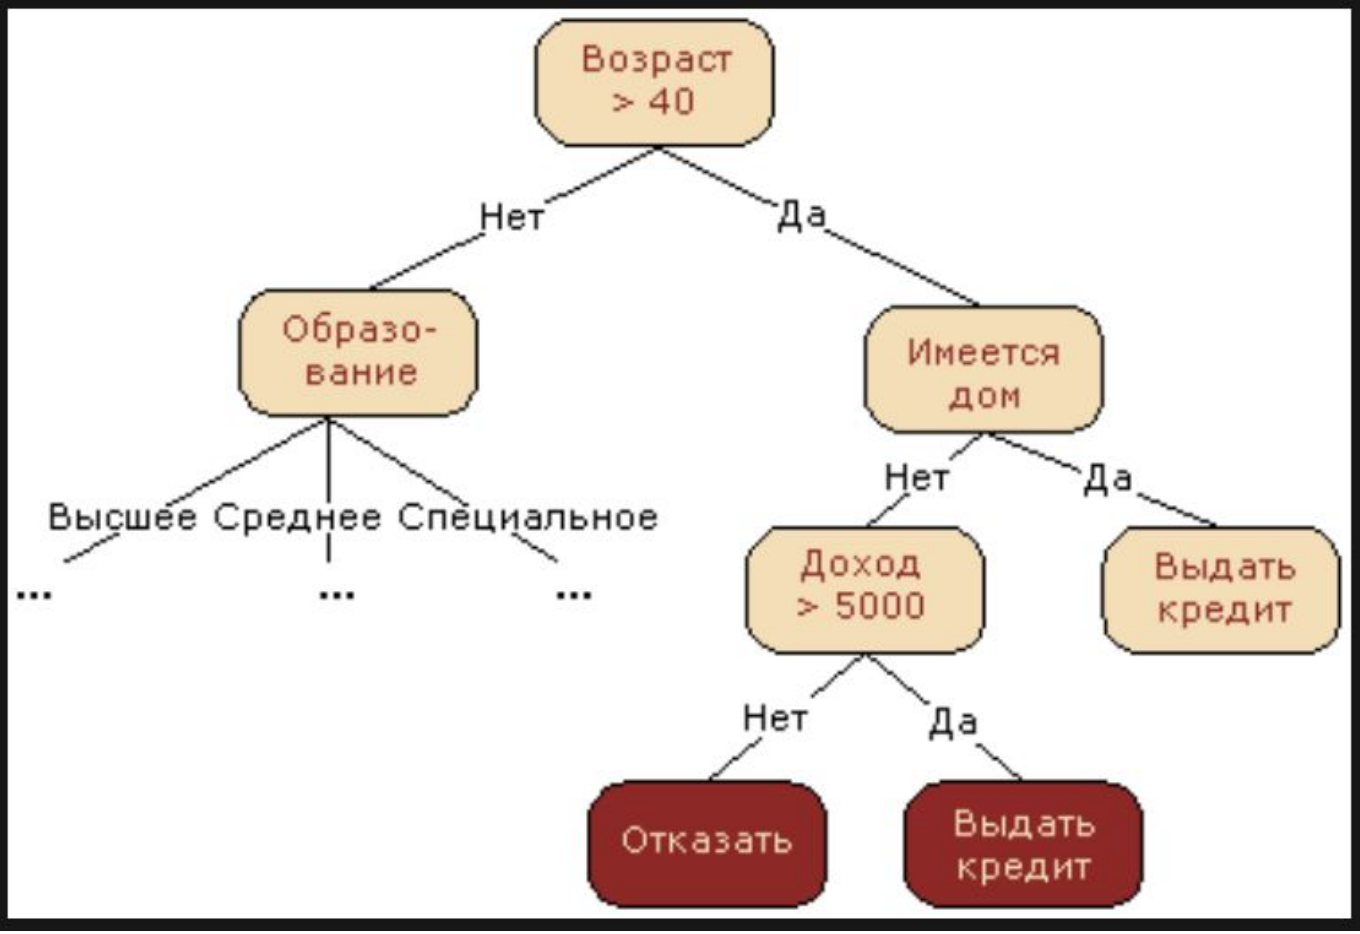

В этом случае можно сказать, что решается задача бинарной классификации (целевой класс имеет два значения:
"Выдать кредит" и "Отказать") по признакам "Возраст", "Наличие дома", "Доход" и "Образование".
Дерево решений как алгоритм машинного обучения – по сути то же самое: объединение логических правил вида
"Значение признака меньше И Значение признака меньше … => Класс 1" в структуру данных "Дерево".

Огромное
**преимущество деревьев решений** в том, что они легко интерпретируемы, понятны человеку. Например, по схеме на
рисунке выше можно объяснить заемщику, почему ему было отказано в кредите. Скажем, потому, что у него нет
дома и доход меньше 5000. Как мы увидим дальше, многие другие, хоть и более точные, модели не обладают этим
свойством и могут рассматриваться скорее как "черный ящик", в который загрузили данные и получили ответ. В
связи с этой "понятностью" деревьев решений и их сходством с моделью принятия решений человеком (можно
легко объяснять боссу свою модель), деревья решений получили огромную популярность

#Критерий информативности

Представьте, что у нас есть данные: мы хотим предсказать, пойдёт ли человек гулять, по погоде (солнечно/пасмурно), ветру (слабый/сильный) и влажности (высокая/низкая). Дерево решений в корне содержит все примеры. Наша задача — выбрать самый лучший признак, по которому мы разделим людей на две группы так, чтобы в каждой группе ответы («гуляет» или «не гуляет») были как можно более **однородными**. Если после разбиения в левой ветке все ответы одинаковые, то мы молодцы — дальше эту ветку можно не дробить.

Как измерить эту «однородность»? Для этого и существуют **критерии информативности** (они же меры нечистоты, impurity measures). Они выдают число: **чем меньше значение, тем чище группа** (тем меньше в ней разнообразие ответов). Идеально чистая группа — все объекты одного класса или с очень близкими значениями — даёт ноль.

В любом листе дерево выдаёт **константу**: для классификации это самый частый класс, для регрессии — среднее или медиана. Поэтому логично оценить качество группы так: **насколько хорошо мы можем предсказать ответы во всей группе одной-единственной константой**? Чем хуже предсказание, тем грязнее группа.

Математически это записывают как:

$$
H(R) = \min_{c} \frac{1}{|R|} \sum_{(x_i, y_i) \in R} L(y_i, c)
$$

Здесь:
- \(R\) — множество объектов в группе;
- \(L(y, c)\) — функция потерь (штраф за то, что истинный ответ \(y\) мы заменили на \(c\));
- \(c\) — та самая константа, которую мы подбираем оптимальной (чтобы минимизировать средний штраф).

То есть \(H(R)\) — это **минимальная средняя ошибка**, которую мы получим, если заменим все ответы одной константой. Именно эту величину мы хотим сделать как можно меньше.

В зависимости от того, что мы считаем функцией потерь, получаются разные известные критерии.

#### Для классификации (ответ — метка класса)

- **Энтропия Шеннона** (Shannon entropy)  
  Функция потерь: логарифмическая (мы штрафуем за предсказание неправильного класса).  
  Если в группе доли классов \(p_1, p_2,..., p_K\), то энтропия считается так:

  $$
  H_{\text{энтр}}(R) = -\sum_{k=1}^{K} p_k \log_2 p_k
  $$

  Почему логарифм? Потому что информация от события с вероятностью \(p\) равна \(-\log p\). Если классы равномерно перемешаны, энтропия максимальна; если один класс доминирует — близка к нулю. Например, для двух классов 50/50 энтропия = 1 бит, для 90/10 ≈ 0.47.

- **Критерий Джини** (Gini impurity)  
  Функция потерь: квадратичная (или вероятность ошибки при случайной классификации).  
  Формула:

  $$
  H_{\text{Джини}}(R) = \sum_{k=1}^{K} p_k (1-p_k) = 1 - \sum_{k=1}^{K} p_k^2
  $$

   Интерпретация: если мы случайно пометим объект из группы меткой, распределённой как \(p_k\), то вероятность ошибки будет \(1 - \sum p_k^2\). Для 50/50: \(1 - 0.5^2 - 0.5^2 = 0.5\), для 90/10: \(1 - 0.81 - 0.01 = 0.18\). Тоже ноль в чистой группе.

- **Ошибка классификации** (misclassification error)  
  Функция потерь: 0-1 (штраф 1, если не угадали класс).  
  Формула:

  $$
  H_{\text{ошиб}}(R) = 1 - \max_k p_k
  $$

  Для 50/50: \(1 - 0.5 = 0.5\), для 90/10: \(0.1\). Она тоже хороша, но менее чувствительна к небольшим изменениям долей, поэтому её реже используют для выбора разбиений (часто применяют как финальную метрику точности).

**Сравнение:** Все три ведут себя похоже, но энтропия чуть более «крутая» (быстрее растёт при смешивании), Джини чаще используют в алгоритме CART (например, в sklearn по умолчанию для деревьев классификации стоит 'gini'). На практике выбор между ними не критичен.


#### Для регрессии (ответ — число)

- **Среднеквадратичная ошибка (MSE, Mean Squared Error)**  
  Функция потерь: квадрат разности \((y - c)^2\). Оптимальная константа — среднее арифметическое \(\bar{y}\). Тогда

  $$
  H_{\text{MSE}}(R) = \frac{1}{|R|} \sum_{i \in R} (y_i - \bar{y})^2
  $$

  Это просто дисперсия целевой переменной в группе. Чем меньше разброс, тем лучше.

- **Средняя абсолютная ошибка (MAE, Mean Absolute Error)**  
  Функция потерь: модуль разности \(|y - c|\). Оптимальная константа — медиана. Тогда

  $$
  H_{\text{MAE}}(R) = \frac{1}{|R|} \sum_{i \in R} |y_i - \text{med}(R)|
  $$

  Менее чувствительна к выбросам, чем MSE.

У нас есть родительская группа Rₘ (перед разбиением) с нечистотой H(Rₘ). Мы рассматриваем некоторый признак и порог, которые делят Rₘ на левую Rₗ и правую Rᵣ группы. После разбиения общая нечистота становится средневзвешенной:

$$
H_{\text{after}} = \frac{|R_\ell|}{|R_m|} H(R_\ell) + \frac{|R_r|}{|R_m|} H(R_r)
$$

Насколько мы улучшили ситуацию? На **прирост информации** (information gain) или **уменьшение нечистоты**:

$$
Q = H(R_m) - H_{\text{after}}
$$

Чем больше \(Q\), тем лучше разбиение. Мы перебираем все возможные признаки и пороги и выбираем тот, который даёт максимальный \(Q\). Затем рекурсивно повторяем для каждой дочерней группы.

#Пример с шариками

**Энтропия Шеннона** (Shannon entropy)  

  $$
  H_{\text{энтр}}(R) = -\sum_{k=1}^{K} p_k \log_2 p_k
  $$

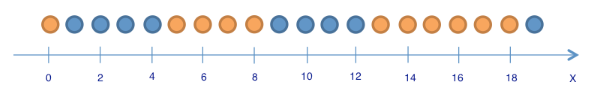

Здесь 9 синих шариков и 11 желтых. Если мы наудачу вытащили шарик, то он с вероятностью $p_1=\frac{9}{20}$ будет синим и с вероятностью $p_2=\frac{11}{20}$ – желтым. Значит, энтропия состояния $S_0 = -\frac{9}{20}\log_2{\frac{9}{20}}-\frac{11}{20}\log_2{\frac{11}{20}} \approx 1$. Само это значение пока ни о чем нам не говорит. Теперь посмотрим, как изменится энтропия, если разбить шарики на две группы – с координатой меньше либо равной 12 и больше 12.

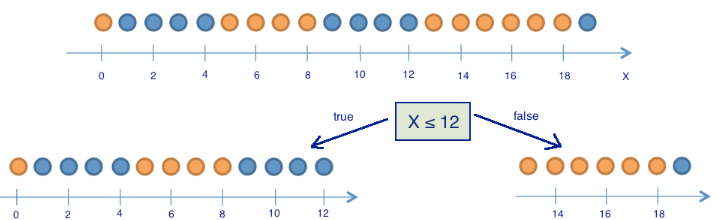

В левой группе оказалось 13 шаров, из которых 8 синих и 5 желтых. Энтропия этой группы равна $S_1 = -\frac{5}{13}\log_2{\frac{5}{13}}-\frac{8}{13}\log_2{\frac{8}{13}} \approx 0.96$. В правой группе оказалось 7 шаров, из которых 1 синий и 6 желтых. Энтропия правой группы равна $S_2 = -\frac{1}{7}\log_2{\frac{1}{7}}-\frac{6}{7}\log_2{\frac{6}{7}} \approx 0.6$. Как видим, энтропия уменьшилась в обеих группах по сравнению с начальным состоянием, хоть в левой и не сильно. Поскольку энтропия – по сути степень хаоса (или неопределенности) в системе, уменьшение энтропии называют приростом информации. Формально прирост информации (information gain, IG) при разбиении выборки по признаку $Q$ (в нашем примере это признак "$x \leq 12$") определяется как

$\Large IG(Q) = S_O - \sum_{i=1}^{q}\frac{N_i}{N}S_i,$

где $q$ – число групп после разбиения, $N_i$ – число элементов выборки, у которых признак $Q$ имеет $i$-ое значение. В нашем случае после разделения получилось две группы ($q = 2$) – одна из 13 элементов ($N_1 = 13$), вторая – из 7 ($N_2 = 7$). Прирост информации получился


$ \Large IG(x \leq 12) = S_0 - \frac{13}{20}S_1 - \frac{7}{20}S_2 \approx 0.16.$

Получается, разделив шарики на две группы по признаку "координата меньше либо равна 12", мы уже получили более упорядоченную систему, чем в начале. Продолжим деление шариков на группы до тех пор, пока в каждой группе шарики не будут одного цвета.

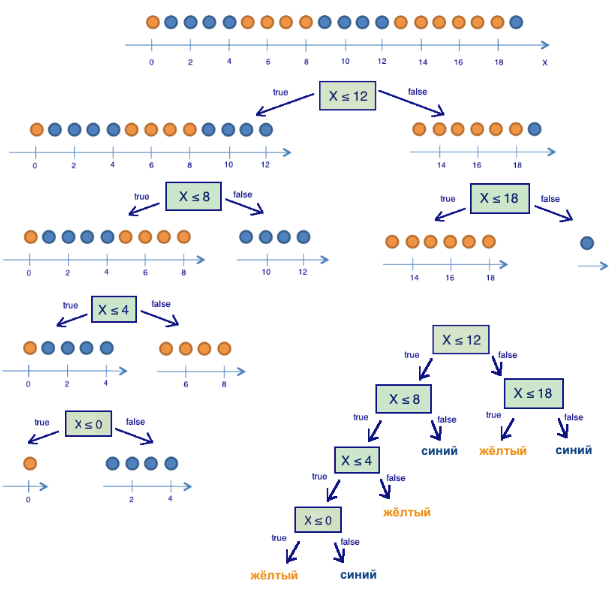

Для правой группы потребовалось всего одно дополнительное разбиение по признаку "координата меньше либо равна 18", для левой – еще три. Очевидно, энтропия группы с шариками одного цвета равна 0 ($\log_2{1} = 0$), что соответствует представлению, что группа шариков одного цвета – упорядоченная.
В итоге мы построили дерево решений, предсказывающее цвет шарика по его координате. Отметим, что такое дерево решений может плохо работать для новых объектов (определения цвета новых шариков), поскольку оно идеально подстроилось под обучающую выборку (изначальные 20 шариков). Для классификации новых шариков лучше подойдет дерево с меньшим числом "вопросов", или разделений, пусть даже оно и не идеально разбивает по цветам обучающую выборку. Эту проблему, переобучение, мы еще рассмотрим далее.

#Код

В Scikit‑learn дерево решений для классификации реализовано в классе sklearn.tree.DecisionTreeClassifier

**Основные параметры класса sklearn.tree.DecisionTreeClassifier**:

max_depth – максимальная глубина дерева


max_features — максимальное число признаков, по которым ищется лучшее разбиение в дереве (это нужно потому, что при большом количестве признаков будет "дорого" искать лучшее (по критерию типа прироста информации) разбиение среди всех признаков)


min_samples_leaf – минимальное число объектов в листе. У этого параметра есть понятная интерпретация: скажем, если он равен 5, то дерево будет порождать только те классифицирующие правила, которые верны как минимум для 5 объектов

Параметры дерева надо настраивать в зависимости от входных данных, и делается это обычно с помощью кросс-валидации.

Параметры важны, чтобы потом оптимизировать модель, так как дерево решений может переобучиться.

**КОГДА возникает переобучение?**
1. **Глубина max_depth=None** (без ограничений)

Дерево растёт до тех пор, пока:
- Каждый лист содержит 1 объект, ИЛИ
- Дальше нельзя разделить (одинаковые признаки)

Плюс: 100% accuracy на train
Минус: шум тоже запомнило

2. **Маленькие листья min_samples_leaf=1**

Лист содержит 1 клиента → слишком узкое правило по 1 случаю, отсутствует обощение

3. **Много признаков без max_features**

100 признаков → дерево ищет идеальные комбинации


**Пример задачи классификации с деревом решений**

По признакам опухоли нужно отнести её к одному из двух классов — злокачественная или доброкачественная.

Загрузим данные, которые уже есть в библиотеке.

load_breast_cancer() возвращает готовый медицинский датасет про опухоли груди.

X — матрица признаков (размер, форма, текстура и т.п. — всё числовое).

y — целевая переменная: 0 или 1 (класс).

class_names — текстовые названия классов: malignant (злокачественная), benign (доброкачественная).
То есть это задача бинарной классификация: предсказать класс опухоли.

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 1. Загружаем датасет из sklearn
data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names
class_names = data.target_names  # ['malignant', 'benign']

# 2. Делим выборку на обучающую (70%) и тестовую (30%).
# stratify=y — сохраняем пропорции классов в train и test (чтобы не оказалось, что в тесте почти нет, например, злокачественных опухолей).
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# 3. Обучаем дерево
clf = DecisionTreeClassifier(
    max_depth=4, #максимальная глубина дерева -- 4
    min_samples_leaf=50, # в каждом листе минимум 50 объектов (чтобы не было правил «по одному пациенту»).
    criterion="gini",
    random_state=42
)
clf.fit(X_train, y_train) #обучаем модель на трейне

# 4. Рисуем дерево
plt.figure(figsize=(20, 8))
plot_tree(
    clf,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    max_depth=4
)
plt.show()

print("Accuracy (test):", accuracy_score(y_test, clf.predict(X_test)))


Визуализация структуры дерева строится так:

в узлах — признак и порог, по которому будет делиться данные например, worst radius <= 16.795)

в листьях — информация о классах:

**samples** = 392 -- общее количество объектов, попавших в этот лист.

**value** = [148, 250] -- распределение объектов по классам в этом листе. [количество класса 0, количество класса 1]. В примере в начале: 148 объектов malignant (злокачественная), 250 benign (доброкачественная).

**gini** = 0.467 -- индекс Джини (неоднородность/нечистота) в листе. Если gini = 0.0, то лист идеально чистый (100% один класс) -- к этому стремится модель.

Давайте еще посморим простой пример дерева решений на задаче бинарной классификации. По 3м признакам: возраст, доход и долг будем решать выдавать ли кредит клиенту или нет. Работаем на синтетических данных


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split

# 1. Создаем простые данные: 3 признака для кредита
np.random.seed(42)
n = 200

age = np.random.randint(20, 65, n) #возраст
income = np.random.randint(10000, 100000, n) // 1000  # доход в тысячах
debt = np.random.randint(0, 50, n)  # долг в тысячах

X = np.column_stack([age, income, debt])
y = ((age > 30) & (income > 30) & (debt < 20)).astype(int) # Клиент получит кредит (y=1), ТОЛЬКО ЕСЛИ: Возраст > 30 И Доход > 30 тыс. И Долг < 20 тыс.
# Иначе y=0 (отказ)

feature_names = ['Возраст', 'Доход (тыс.)', 'Долг (тыс.)']
class_names = ['Отказ', 'Одобрить']

# 2. Делим на train и Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42  # 70% train, 30% test
)

print(f"Train: {len(X_train)} объектов, Test: {len(X_test)} объектов")

# 3. Обучаем дерево
clf = DecisionTreeClassifier(max_depth=3, criterion="gini", random_state=42)
clf.fit(X_train, y_train)

# 4. Рисуем дерево
plt.figure(figsize=(12, 8))
plot_tree(clf,
          feature_names=feature_names,
          class_names=class_names,
          filled=True,
          rounded=True,
          fontsize=14)
plt.title("Одобрение кредита: простое дерево", fontsize=16, pad=20)
plt.show()

# 5. Проверяем качество
print(f"Accuracy train: {np.mean(clf.predict(X_train) == y_train):.3f}")
print(f"Accuracy test:  {np.mean(clf.predict(X_test) == y_test):.3f}")


Предыдущий пример — бинарная классификация (2 класса: одобрено/отказ).

Вот пример многоклассовой классификации — сегментация клиентов розничной сети (4 класса клиентов по ценности для бизнеса).

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 1. Генерируем данные: сегментация клиентов
np.random.seed(42)
n_samples = 800

# Признаки
age = np.random.normal(40, 12, n_samples) #возраст
annual_spend = np.random.lognormal(10, 0.8, n_samples)  # годовые траты
visits_per_month = np.random.poisson(8, n_samples) #визиты за месяц
has_membership = np.random.binomial(1, 0.3, n_samples) #есть ли membership

X = np.column_stack([age, annual_spend, visits_per_month, has_membership]) #объединяем все признаки в одну матрицу по клиентам и сохраняем это в переменную X
feature_names = ['Age', 'Annual_spend', 'Visits_month', 'Membership']

# Задаем функцию для определения 4 КЛАССОВ клиентов (мультиклассовая классификация!)
def client_segment(row):
    spend, visits = row[1], row[2]
    if spend > 30000 and visits > 15:
        return 3  # VIP
    elif spend > 15000:
        return 2  # Премиум
    elif spend > 5000 or visits > 8:
        return 1  # Обычный
    else:
        return 0  # Низкоценный клиент

y = np.array([client_segment(row) for row in X]) + np.random.binomial(1, 0.15, n_samples) #в переменную y заносим наши определения класса с помощью созданной функции и добавляем немного шума
y = np.clip(y, 0, 3) #Ограничиваем классы от 0 до 3 (не даём уйти за границы).

class_names = ['Низкоценный клиент', 'Обычный', 'Премиум', 'VIP']

# 2. Делим данные на train и test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# 3. Обучаем дерево для МУЛЬТИКЛАССА
clf = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=20,
    criterion="gini",  # работает для >2 классов
    random_state=42
)
clf.fit(X_train, y_train)

# 4. ВИЗУАЛИЗАЦИЯ — теперь 4 класса
plt.figure(figsize=(20, 12))
plot_tree(
    clf,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    fontsize=11
)
plt.title("Многоклассовая классификация. Сегментация клиентов", fontsize=16, pad=20)
plt.show()

print(f"Accuracy (test): {accuracy_score(y_test, clf.predict(X_test)):.3f}")

# 5. Распределение классов в листьях (пример анализа)
print("\nПример листьев:")
unique_leaves = np.unique(clf.apply(X_train))
for leaf_id in unique_leaves[:3]:  # первые 3 листа
    leaf_mask = clf.apply(X_train) == leaf_id
    counts = np.bincount(y_train[leaf_mask], minlength=4)
    print(f"Лист {leaf_id}: {dict(zip(class_names, counts))} -> класс {np.argmax(counts)}")


Что изменилось в многоклассовой классификации

1. 4 класса вместо 2

y ∈ {0,1,2,3} вместо y ∈ {0,1}

Классы: ['Низкоценный клиент', 'Обычный', 'Премиум', 'VIP']

2. В листьях теперь value = [n0, n1, n2, n3]
Пример листа:
value = [10, 25, 8, 2]  # 10 низкоценных клиентов, 25 обычных, 8 премиум, 2 VIP

3. Gini для многокласса

Gini = 1 - Σ(p_i²), где i = 0,1,2,3
Пример: p = [0.25, 0.5, 0.2, 0.05]
Gini = 1 - (0.25² + 0.5² + 0.2² + 0.05²) = 1 - 0.3625 = 0.6375

**Задание 1**: Предсказание отклика на email-рассылку

**Сценарий**

Интернет-магазин отправляет email-рассылку со скидкой 20%. Нужно предсказать, откликнется ли клиент (купит товар после письма).

**Признаки:**

days_since_last_purchase — дней с последней покупки

total_orders — всего заказов за всё время

open_rate — % писем, которые открывает (0-100)

In [ ]:
# Данные для вашей работы уже созданы
import numpy as np
np.random.seed(123)

n = 250
days_since = np.random.poisson(30, n)
total_orders = np.random.poisson(4, n)
open_rate = np.random.normal(25, 15, n)
open_rate = np.clip(open_rate, 0, 100)

X = np.column_stack([days_since, total_orders, open_rate])
feature_names = ['Дни_с_посл_покупки', 'Всего_заказов', '%_открытий']


In [ ]:
# 1. Создай y (отклик=1, нет=0)
# Логика: активные клиенты с высоким open_rate откликаются
# Напиши свою формулу. Пример:
# y = ((days_since < 45) & (total_orders > 2) & (open_rate > 20)).astype(int)

y = (
    ((days_since < 45) & (total_orders > 2) & (open_rate > 20)) |
    ((days_since < 20) & (open_rate > 35))
).astype(int)


# 2. Раздели данные на Train и Test 70/30
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 3. Обучи дерево
from sklearn.tree import DecisionTreeClassifier
clf = DecisionTreeClassifier(max_depth=2, random_state=42)
clf.fit(X_train, y_train)

# Проверим качество на train и test
from sklearn.metrics import accuracy_score
print(f"Доля откликов в данных: {y.mean():.3f}")
print(f"Accuracy train: {accuracy_score(y_train, clf.predict(X_train)):.3f}")
print(f"Accuracy test:  {accuracy_score(y_test, clf.predict(X_test)):.3f}")

# 4. Нарисуй дерево
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
plt.figure(figsize=(12,8))
plot_tree(clf, feature_names=feature_names, class_names=['Нет', 'Да'],
          filled=True, rounded=True)
plt.show()


Вопросы на самопроверку:
1. Что произойдет, если не ограничивать глубину дерева?

Ответ: дерево может разрастись до очень глубокого и почти идеально запомнить обучающую выборку. Это приведет к переобучению: качество на train будет высоким, но на новых клиентах модель может работать хуже.

2. Как дерево принимает решение о классе?

Ответ: объект проходит от корня к листу по условиям на признаки. В каждом узле проверяется правило вида «признак <= порог». В листе дерево смотрит, какой класс встречается чаще всего среди обучающих объектов этого листа, и предсказывает этот класс.

3. Что произойдет, если в листе 60% объектов класса A и 40% класса B?

Ответ: дерево выберет класс A, потому что он является большинством в листе. Для классификации также можно интерпретировать доли как оценку вероятностей: примерно 0.6 для класса A и 0.4 для класса B.


# На примере регрессии

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree

In [ ]:
# iris = load_iris()
# X_clf = iris.data[:, :2]  # sepal length, sepal width
# y_clf = iris.target

# # Обучаем дерево классификации с энтропией, глубины 3
# clf = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)
# clf.fit(X_clf, y_clf)

# # Рисуем дерево классификации
# plt.figure(figsize=(16, 8))
# plot_tree(clf,
#           feature_names=['sepal length', 'sepal width'],
#           class_names=iris.target_names,
#           filled=True,
#           rounded=True,
#           fontsize=12,
#           proportion=False)
# plt.title('Дерево классификации (критерий = энтропия)')
# plt.show()

In [ ]:
np.random.seed(42)
X_reg = np.linspace(0, 10, 50).reshape(-1, 1)
y_reg = 2 * X_reg.ravel() * np.sin(X_reg.ravel()) + np.random.normal(0, 1, size=50)

# Обучаем дерево регрессии с MSE (теперь 'squared_error'), глубины 3
reg = DecisionTreeRegressor(criterion='squared_error', max_depth=3, random_state=42)
reg.fit(X_reg, y_reg)

# Рисуем дерево регрессии
plt.figure(figsize=(21, 8))
plot_tree(reg,
          feature_names=['X'],
          filled=True,
          rounded=True,
          fontsize=12,
          proportion=False)
plt.title('Дерево регрессии (критерий = squared_error)')
plt.show()

Дерево делит всё пространство признака (здесь только X) на отрезки. В каждом отрезке предсказание постоянно.

*   squared_error — это мера того, насколько хорошо отрезок «собирает» близкие значения. Чем меньше, тем лучше.

*   samples — сколько точек попало в этот отрезок (важно для оценки надёжности).

*   value — ответ для всех точек этого отрезка.